In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [3]:
# Keep only the columns needed for Week 3
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']].copy()

# Remove rows with missing Age values
df_age = df.dropna(subset=['Age'])

print("Original rows:", len(df))
print("Rows available for age analysis:", len(df_age))

print("\nMissing values after preparation:")
print(df.isnull().sum())

Original rows: 891
Rows available for age analysis: 714

Missing values after preparation:
Survived      0
Pclass        0
Sex           0
Age         177
Fare          0
dtype: int64


In [4]:
# Descriptive statistics for survivors and non-survivors

survivors = df_age[df_age['Survived'] == 1]['Age']
non_survivors = df_age[df_age['Survived'] == 0]['Age']

print("SURVIVORS")
print("Mean age:", survivors.mean())
print("Standard deviation:", survivors.std())
print("Number of passengers:", len(survivors))

print("\nNON-SURVIVORS")
print("Mean age:", non_survivors.mean())
print("Standard deviation:", non_survivors.std())
print("Number of passengers:", len(non_survivors))

print("\nDifference in mean age:",
      survivors.mean() - non_survivors.mean())

SURVIVORS
Mean age: 28.343689655172415
Standard deviation: 14.950951984140426
Number of passengers: 290

NON-SURVIVORS
Mean age: 30.62617924528302
Standard deviation: 14.17210987713849
Number of passengers: 424

Difference in mean age: -2.282489590110604


In [6]:
from scipy import stats

In [7]:
# Step 5: Independent Two-Sample t-test

t_stat, p_value = stats.ttest_ind(
    survivors,
    non_survivors,
    equal_var=False
)

print("Independent Two-Sample t-test")
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("\nDecision: Reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference in the mean ages.")
else:
    print("\nDecision: Fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant difference in the mean ages.")

Independent Two-Sample t-test
t-statistic: -2.0460301043939704
p-value: 0.04118965162586639

Decision: Reject the null hypothesis.
Conclusion: There is a statistically significant difference in the mean ages.


In [9]:
import numpy as np
from scipy import stats

mean_diff = survivors.mean() - non_survivors.mean()

se = np.sqrt(
    survivors.var(ddof=1) / len(survivors) +
    non_survivors.var(ddof=1) / len(non_survivors)
)

df_welch = (
    (survivors.var(ddof=1) / len(survivors) +
     non_survivors.var(ddof=1) / len(non_survivors)) ** 2
    /
    (
        (survivors.var(ddof=1) / len(survivors)) ** 2 / (len(survivors) - 1)
        +
        (non_survivors.var(ddof=1) / len(non_survivors)) ** 2 / (len(non_survivors) - 1)
    )
)

critical_value = stats.t.ppf(0.975, df_welch)

margin_of_error = critical_value * se

ci_lower = mean_diff - margin_of_error
ci_upper = mean_diff + margin_of_error

print("Mean age difference:", mean_diff)
print("95% Confidence Interval:", ci_lower, "to", ci_upper)

Mean age difference: -2.282489590110604
95% Confidence Interval: -4.47339446031757 to -0.09158471990363815


In [10]:
# Step 7: Age Distribution by Survival

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_age,
    x='Survived',
    y='Age'
)

plt.title('Age Distribution of Survivors and Non-Survivors')
plt.xlabel('Survival Status (0 = Did Not Survive, 1 = Survived)')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [11]:
# WEEK 3 - SETUP AND DATA PREPARATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Select required columns
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']].copy()

# Remove missing Age values
df_age = df.dropna(subset=['Age']).copy()

# Create survivor and non-survivor groups
survivors = df_age.loc[df_age['Survived'] == 1, 'Age']
non_survivors = df_age.loc[df_age['Survived'] == 0, 'Age']

print("Week 3 dataset loaded successfully!")
print("Total passengers:", len(df))
print("Passengers used for age analysis:", len(df_age))
print("Survivors:", len(survivors))
print("Non-survivors:", len(non_survivors))

Week 3 dataset loaded successfully!
Total passengers: 891
Passengers used for age analysis: 714
Survivors: 290
Non-survivors: 424


In [12]:
# STEP 2: DESCRIPTIVE STATISTICS

print("SURVIVORS")
print("Mean age:", round(survivors.mean(), 2))
print("Standard deviation:", round(survivors.std(), 2))
print("Number of passengers:", len(survivors))

print("\nNON-SURVIVORS")
print("Mean age:", round(non_survivors.mean(), 2))
print("Standard deviation:", round(non_survivors.std(), 2))
print("Number of passengers:", len(non_survivors))

SURVIVORS
Mean age: 28.34
Standard deviation: 14.95
Number of passengers: 290

NON-SURVIVORS
Mean age: 30.63
Standard deviation: 14.17
Number of passengers: 424


In [13]:
# STEP 3: INDEPENDENT TWO-SAMPLE T-TEST

t_statistic, p_value = stats.ttest_ind(
    survivors,
    non_survivors,
    equal_var=False
)

print("t-statistic:", round(t_statistic, 4))
print("p-value:", round(p_value, 4))

if p_value < 0.05:
    print("Decision: Reject the null hypothesis.")
else:
    print("Decision: Fail to reject the null hypothesis.")

t-statistic: -2.046
p-value: 0.0412
Decision: Reject the null hypothesis.


In [14]:
# STEP 4: 95% CONFIDENCE INTERVAL

result = stats.ttest_ind(
    survivors,
    non_survivors,
    equal_var=False
)

ci = result.confidence_interval(confidence_level=0.95)

print("95% Confidence Interval")
print("Lower limit:", round(ci.low, 4))
print("Upper limit:", round(ci.high, 4))

95% Confidence Interval
Lower limit: -4.4734
Upper limit: -0.0916


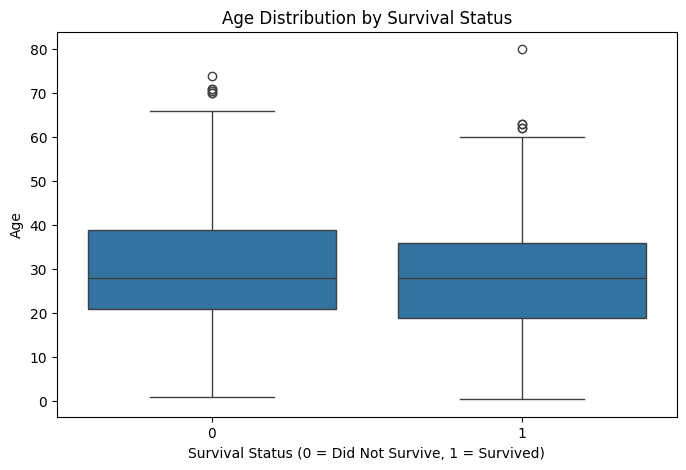

In [15]:
# STEP 5: BOX PLOT

plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Survived',
    y='Age',
    data=df_age
)

plt.title('Age Distribution by Survival Status')
plt.xlabel('Survival Status (0 = Did Not Survive, 1 = Survived)')
plt.ylabel('Age')

plt.show()

In [16]:
# STEP 6: CONTINGENCY TABLE

contingency_table = pd.crosstab(
    df['Sex'],
    df['Survived']
)

print("Contingency Table:")
print(contingency_table)

Contingency Table:
Survived    0    1
Sex               
female     81  233
male      468  109


In [17]:
# STEP 7: CHI-SQUARE TEST OF INDEPENDENCE

chi2, p_value, degrees_of_freedom, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", round(chi2, 4))
print("p-value:", round(p_value, 4))
print("Degrees of freedom:", degrees_of_freedom)

if p_value < 0.05:
    print("Decision: Reject the null hypothesis.")
    print("Conclusion: Gender and survival are statistically associated.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("Conclusion: No statistically significant association was found.")

Chi-square statistic: 260.717
p-value: 0.0
Degrees of freedom: 1
Decision: Reject the null hypothesis.
Conclusion: Gender and survival are statistically associated.


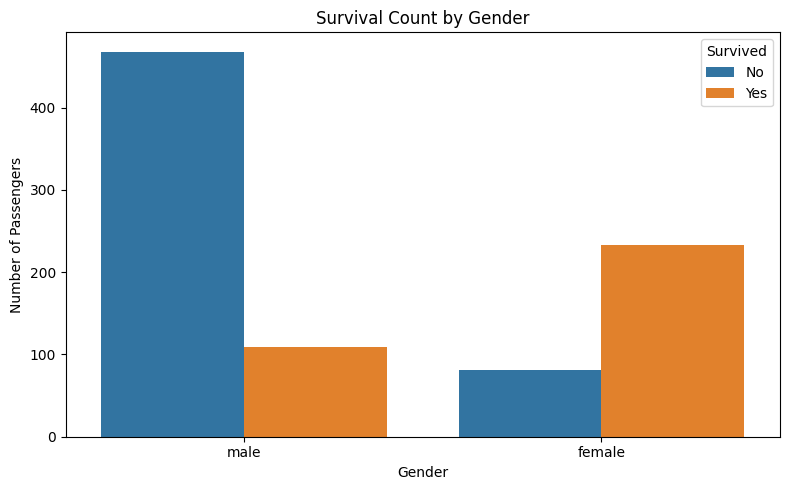

In [18]:
# STEP 8: SURVIVAL COUNT BY GENDER

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Sex',
    hue='Survived'
)

plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(
    title='Survived',
    labels=['No', 'Yes']
)

plt.tight_layout()
plt.show()

In [19]:
# STEP 9: PREPARE FARE GROUPS

class_1 = df[df['Pclass'] == 1]['Fare'].dropna()
class_2 = df[df['Pclass'] == 2]['Fare'].dropna()
class_3 = df[df['Pclass'] == 3]['Fare'].dropna()

print("Class 1 passengers:", len(class_1))
print("Class 2 passengers:", len(class_2))
print("Class 3 passengers:", len(class_3))

Class 1 passengers: 216
Class 2 passengers: 184
Class 3 passengers: 491


In [20]:
# STEP 10: ONE-WAY ANOVA TEST

f_statistic, p_value = stats.f_oneway(
    class_1,
    class_2,
    class_3
)

print("F-statistic:", round(f_statistic, 4))
print("p-value:", round(p_value, 4))

if p_value < 0.05:
    print("Decision: Reject the null hypothesis.")
    print("Conclusion: Mean fares differ significantly across passenger classes.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("Conclusion: No significant difference in mean fares was found.")

F-statistic: 242.3442
p-value: 0.0
Decision: Reject the null hypothesis.
Conclusion: Mean fares differ significantly across passenger classes.


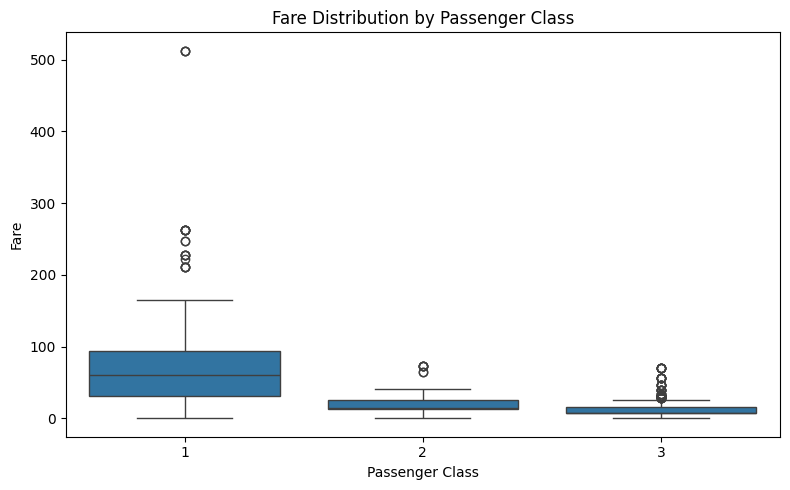

In [21]:
# STEP 11: FARE DISTRIBUTION BY PASSENGER CLASS

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Pclass',
    y='Fare'
)

plt.title('Fare Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')

plt.tight_layout()
plt.show()

In [22]:
# STEP 12: DESCRIPTIVE STATISTICS FOR FARE

print("Mean Fare by Passenger Class")

print("Class 1:", round(class_1.mean(), 2))
print("Class 2:", round(class_2.mean(), 2))
print("Class 3:", round(class_3.mean(), 2))

Mean Fare by Passenger Class
Class 1: 84.15
Class 2: 20.66
Class 3: 13.68


In [23]:
# STEP 13: FINAL STATISTICAL RESULTS SUMMARY

# Recalculate each test with separate variable names

t_stat, t_p = stats.ttest_ind(
    survivors,
    non_survivors,
    equal_var=False
)

chi_stat, chi_p, chi_df, expected = stats.chi2_contingency(
    contingency_table
)

anova_stat, anova_p = stats.f_oneway(
    class_1,
    class_2,
    class_3
)

print("========== WEEK 3 STATISTICAL RESULTS ==========\n")

print("1. T-TEST: AGE vs SURVIVAL")
print("t-statistic:", round(t_stat, 4))
print("p-value:", round(t_p, 4))

print("\n2. CHI-SQUARE TEST: GENDER vs SURVIVAL")
print("Chi-square statistic:", round(chi_stat, 4))
print("p-value:", round(chi_p, 4))
print("Degrees of freedom:", chi_df)

print("\n3. ANOVA: FARE vs PASSENGER CLASS")
print("F-statistic:", round(anova_stat, 4))
print("p-value:", round(anova_p, 4))

print("\n========== ANALYSIS COMPLETE ==========")

========== WEEK 3 STATISTICAL RESULTS ==========

1. T-TEST: AGE vs SURVIVAL
t-statistic: -2.046
p-value: 0.0412

2. CHI-SQUARE TEST: GENDER vs SURVIVAL
Chi-square statistic: 260.717
p-value: 0.0
Degrees of freedom: 1

3. ANOVA: FARE vs PASSENGER CLASS
F-statistic: 242.3442
p-value: 0.0

========== ANALYSIS COMPLETE ==========


In [24]:
# STEP 15: EFFECT SIZE (COHEN'S d)

mean_difference = survivors.mean() - non_survivors.mean()

pooled_std = np.sqrt(
    (
        (len(survivors) - 1) * survivors.var(ddof=1)
        +
        (len(non_survivors) - 1) * non_survivors.var(ddof=1)
    )
    /
    (len(survivors) + len(non_survivors) - 2)
)

cohens_d = mean_difference / pooled_std

print("Mean age difference:", round(mean_difference, 4))
print("Cohen's d:", round(cohens_d, 4))

Mean age difference: -2.2825
Cohen's d: -0.1575


In [25]:
# STEP 16: CRAMER'S V EFFECT SIZE

n = contingency_table.to_numpy().sum()
min_dimension = min(contingency_table.shape) - 1

cramers_v = np.sqrt(
    chi_stat / (n * min_dimension)
)

print("Cramer's V:", round(cramers_v, 4))

Cramer's V: 0.5409


In [26]:
# STEP 17: ANOVA EFFECT SIZE (ETA SQUARED)

grand_mean = df['Fare'].dropna().mean()

ss_between = (
    len(class_1) * (class_1.mean() - grand_mean) ** 2
    + len(class_2) * (class_2.mean() - grand_mean) ** 2
    + len(class_3) * (class_3.mean() - grand_mean) ** 2
)

ss_total = ((df['Fare'].dropna() - grand_mean) ** 2).sum()

eta_squared = ss_between / ss_total

print("Eta squared:", round(eta_squared, 4))

Eta squared: 0.3531


In [27]:
# STEP 18: FINAL RESULTS

print("========== FINAL WEEK 3 RESULTS ==========")

print("\n1. AGE vs SURVIVAL - T-TEST")
print("t-statistic:", round(t_stat, 4))
print("p-value:", round(t_p, 4))
print("Mean age difference:", round(mean_difference, 4))
print("Cohen's d:", round(cohens_d, 4))

print("\n2. GENDER vs SURVIVAL - CHI-SQUARE")
print("Chi-square:", round(chi_stat, 4))
print("p-value: < 0.001")
print("Degrees of freedom:", chi_df)
print("Cramer's V:", round(cramers_v, 4))

print("\n3. FARE vs PASSENGER CLASS - ANOVA")
print("F-statistic:", round(anova_stat, 4))
print("p-value: < 0.001")
print("Eta squared:", round(eta_squared, 4))

print("\n========== ANALYSIS COMPLETE ==========")

========== FINAL WEEK 3 RESULTS ==========

1. AGE vs SURVIVAL - T-TEST
t-statistic: -2.046
p-value: 0.0412
Mean age difference: -2.2825
Cohen's d: -0.1575

2. GENDER vs SURVIVAL - CHI-SQUARE
Chi-square: 260.717
p-value: < 0.001
Degrees of freedom: 1
Cramer's V: 0.5409

3. FARE vs PASSENGER CLASS - ANOVA
F-statistic: 242.3442
p-value: < 0.001
Eta squared: 0.3531

========== ANALYSIS COMPLETE ==========


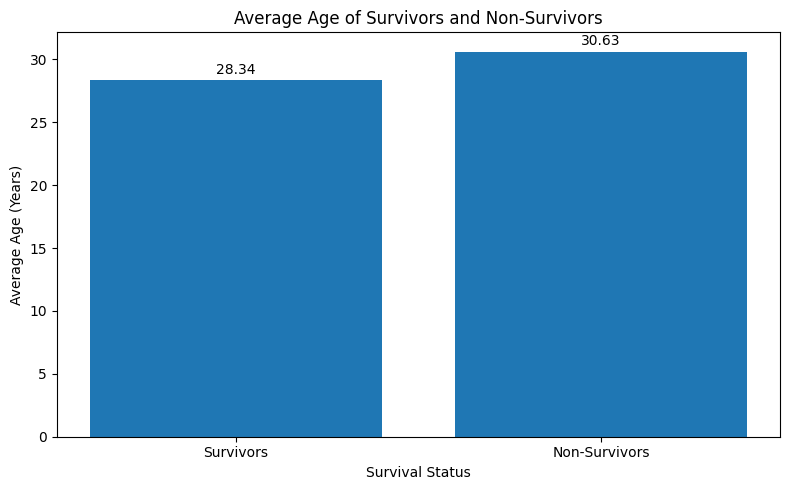

In [28]:
# STEP 19: MEAN AGE COMPARISON

mean_ages = [
    survivors.mean(),
    non_survivors.mean()
]

labels = ['Survivors', 'Non-Survivors']

plt.figure(figsize=(8, 5))

plt.bar(labels, mean_ages)

plt.title('Average Age of Survivors and Non-Survivors')
plt.xlabel('Survival Status')
plt.ylabel('Average Age (Years)')

for i, value in enumerate(mean_ages):
    plt.text(i, value + 0.5, f'{value:.2f}', ha='center')

plt.tight_layout()
plt.show()

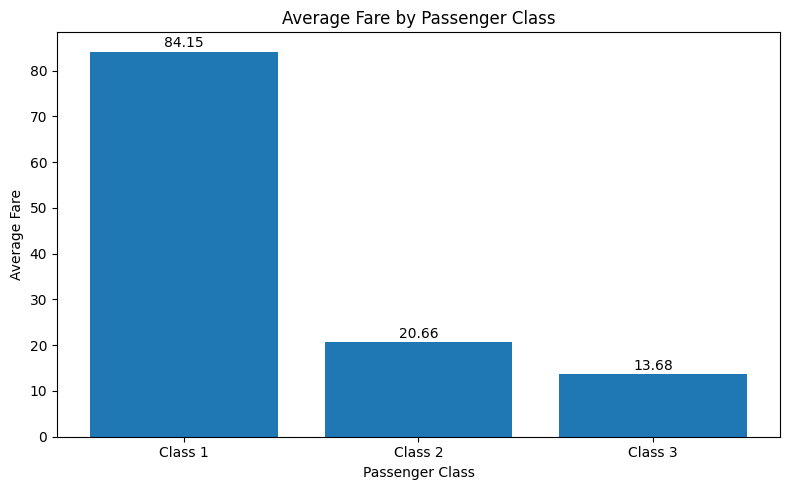

In [29]:
# STEP 20: MEAN FARE BY PASSENGER CLASS

mean_fares = [
    class_1.mean(),
    class_2.mean(),
    class_3.mean()
]

labels = ['Class 1', 'Class 2', 'Class 3']

plt.figure(figsize=(8, 5))

plt.bar(labels, mean_fares)

plt.title('Average Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Average Fare')

for i, value in enumerate(mean_fares):
    plt.text(i, value + 1, f'{value:.2f}', ha='center')

plt.tight_layout()
plt.show()